# 🌀 Gaussian Mixture Models — Soft, Probabilistic Clustering

Every clustering method so far has given each point exactly one cluster label. A Gaussian Mixture Model gives each point a *probability distribution* over clusters instead -- "70% likely in cluster A, 30% likely in cluster B" is a valid, meaningful GMM output. GMM also generalizes K-Means directly: K-Means turns out to be a special, restricted case of GMM (spherical clusters, hard assignment, equal weights), fit with a simpler algorithm. This notebook derives the EM algorithm that fits a GMM, then re-tests DBSCAN's varying-density failure case and K-Means' elliptical-cluster limitation to see whether GMM's added flexibility actually fixes them.

📖 Full mathematical explanation (the mixture model, the EM algorithm derivation, BIC/AIC model selection): [README.md](README.md)


## 1. Setup & Datasets

The same blobs, moons, and Iris datasets used in every clustering topic so far, plus the exact varying-density dataset that broke DBSCAN in the previous topic, plus a new elliptical-clusters dataset built specifically to test what spherical-only methods (K-Means) cannot represent.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal
from sklearn.datasets import make_blobs, make_moons, load_iris
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
X_blobs, y_blobs_true = make_blobs(n_samples=300, centers=4, cluster_std=0.9, random_state=42)
X_moons, y_moons_true = make_moons(n_samples=300, noise=0.08, random_state=42)
iris = load_iris()
X_iris, y_iris_true = iris.data, iris.target
print(f"Blobs: {X_blobs.shape}, Moons: {X_moons.shape}, Iris: {X_iris.shape}")
print("(Identical datasets to every prior clustering topic -- every ARI below is directly comparable.)")


Blobs: (300, 2), Moons: (300, 2), Iris: (150, 4)
(Identical datasets to every prior clustering topic -- every ARI below is directly comparable.)


In [3]:
dense_cluster, _ = make_blobs(n_samples=200, centers=[[0, 0]], cluster_std=0.3, random_state=1)
sparse_cluster, _ = make_blobs(n_samples=100, centers=[[8, 8]], cluster_std=1.8, random_state=1)
X_varying_density = np.vstack([dense_cluster, sparse_cluster])
true_density_labels = np.array([0] * len(dense_cluster) + [1] * len(sparse_cluster))
print(f"Varying-density dataset (identical to the DBSCAN topic's failure case): {X_varying_density.shape}")


Varying-density dataset (identical to the DBSCAN topic's failure case): (300, 2)


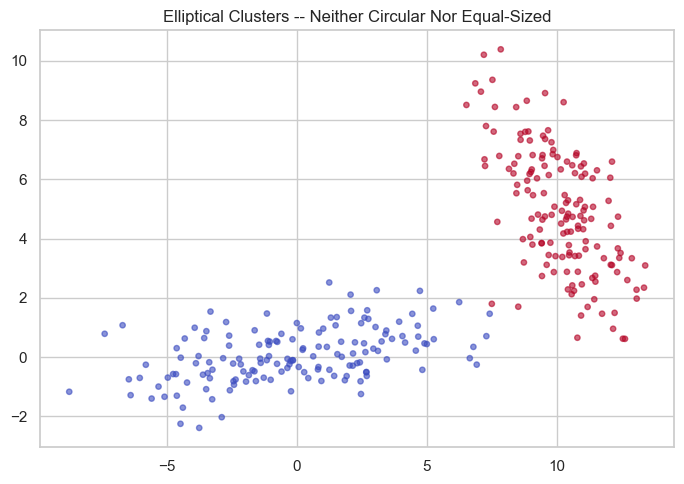

In [4]:
rng = np.random.RandomState(5)
transform_a = np.array([[3, 1.5], [0, 1]])
transform_b = np.array([[1, -1], [0.5, 2]])
cluster_ell_a = rng.normal(size=(150, 2)) @ transform_a.T + [0, 0]
cluster_ell_b = rng.normal(size=(150, 2)) @ transform_b.T + [10, 5]
X_elliptical = np.vstack([cluster_ell_a, cluster_ell_b])
y_elliptical_true = np.array([0] * 150 + [1] * 150)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_elliptical[:, 0], X_elliptical[:, 1], c=y_elliptical_true, cmap="coolwarm", alpha=0.6, s=15)
ax.set_title("Elliptical Clusters -- Neither Circular Nor Equal-Sized")
plt.tight_layout()
plt.show()


## 2. The Mixture Model

$$p(x) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x \mid \mu_k, \Sigma_k)$$

The data is modeled as generated by $K$ Gaussian components, each with its own mean $\mu_k$, covariance $\Sigma_k$, and mixing weight $\pi_k$ (with $\sum_k \pi_k = 1$). Fitting means finding the $(\pi_k, \mu_k, \Sigma_k)$ that maximize the likelihood of the observed data -- but unlike linear regression's closed-form normal equation, this has no closed-form solution because the cluster assignments themselves are unknown.


In [5]:
def e_step(X, means, covariances, weights):
    n, k = len(X), len(means)
    responsibilities = np.zeros((n, k))
    for j in range(k):
        responsibilities[:, j] = weights[j] * multivariate_normal.pdf(X, mean=means[j], cov=covariances[j])
    responsibilities /= responsibilities.sum(axis=1, keepdims=True)
    return responsibilities

def m_step(X, responsibilities, reg_covar=1e-6):
    n, k = len(X), responsibilities.shape[1]
    Nk = responsibilities.sum(axis=0)
    weights = Nk / n
    means = np.array([np.sum(responsibilities[:, j:j+1] * X, axis=0) / Nk[j] for j in range(k)])
    covariances = []
    for j in range(k):
        diff = X - means[j]
        cov = (responsibilities[:, j:j+1] * diff).T @ diff / Nk[j]
        cov += reg_covar * np.eye(X.shape[1])  # avoids singular/collapsed covariance, same fix sklearn applies internally
        covariances.append(cov)
    return means, np.array(covariances), weights

print("E-step (compute responsibilities) and M-step (update parameters) defined.")
print("Note: M-step adds a small reg_covar term to each covariance matrix -- without it, a component can collapse onto too few points and its covariance becomes singular, crashing the density calculation. This is the same reg_covar fix sklearn's GaussianMixture applies internally by default.")


E-step (compute responsibilities) and M-step (update parameters) defined.
Note: M-step adds a small reg_covar term to each covariance matrix -- without it, a component can collapse onto too few points and its covariance becomes singular, crashing the density calculation. This is the same reg_covar fix sklearn's GaussianMixture applies internally by default.


## 3. GMM From Scratch

Alternate E-step and M-step until the log-likelihood stops improving -- exactly the same alternating-optimization pattern as K-Means' assign/update loop, but computing soft probabilities instead of hard assignments, and full Gaussian parameters instead of just a centroid.


In [6]:
def gmm_from_scratch(X, k, n_iterations=100, random_state=0, init_means=None, init_covariances=None, init_weights=None):
    rng = np.random.RandomState(random_state)
    n, d = X.shape
    if init_means is None:
        init_idx = rng.choice(n, size=k, replace=False)
        init_means = X[init_idx].copy()
    if init_covariances is None:
        init_covariances = np.array([np.cov(X.T) for _ in range(k)])
    if init_weights is None:
        init_weights = np.full(k, 1 / k)

    means, covariances, weights = init_means.copy(), init_covariances.copy(), init_weights.copy()
    log_likelihood_history = []

    for _ in range(n_iterations):
        resp = e_step(X, means, covariances, weights)
        means, covariances, weights = m_step(X, resp)
        total_density = sum(weights[j] * multivariate_normal.pdf(X, mean=means[j], cov=covariances[j]) for j in range(k))
        log_likelihood_history.append(np.sum(np.log(total_density)))
        if len(log_likelihood_history) > 1 and abs(log_likelihood_history[-1] - log_likelihood_history[-2]) < 1e-6:
            break

    return means, covariances, weights, log_likelihood_history

print("From-scratch GMM (EM loop) defined, with optional explicit initial parameters for fair same-start comparisons.")


From-scratch GMM (EM loop) defined, with optional explicit initial parameters for fair same-start comparisons.


In [7]:
rng_init = np.random.RandomState(1)
shared_init_idx = rng_init.choice(len(X_blobs), size=4, replace=False)
shared_init_means = X_blobs[shared_init_idx].copy()
shared_init_covariances = np.array([np.cov(X_blobs.T) for _ in range(4)])
shared_init_weights = np.full(4, 1 / 4)

manual_means, manual_covs, manual_weights, manual_ll_history = gmm_from_scratch(
    X_blobs, k=4, init_means=shared_init_means, init_covariances=shared_init_covariances, init_weights=shared_init_weights
)
print(f"Manual GMM converged in {len(manual_ll_history)} iterations")
print(f"Final log-likelihood: {manual_ll_history[-1]:.2f}")


Manual GMM converged in 23 iterations
Final log-likelihood: -1267.60


In [8]:
sklearn_gmm = GaussianMixture(
    n_components=4, n_init=1,
    means_init=shared_init_means,
    precisions_init=np.array([np.linalg.inv(c) for c in shared_init_covariances]),
    weights_init=shared_init_weights,
).fit(X_blobs)

sklearn_ll = sklearn_gmm.score(X_blobs) * len(X_blobs)
print(f"Manual final means (same starting point):\n{np.round(np.sort(manual_means, axis=0), 2)}")
print(f"sklearn final means (same starting point):\n{np.round(np.sort(sklearn_gmm.means_, axis=0), 2)}")
print(f"Manual log-likelihood:  {manual_ll_history[-1]:.2f}")
print(f"sklearn log-likelihood: {sklearn_ll:.2f}")
print(f"Close match? {abs(manual_ll_history[-1] - sklearn_ll) / abs(sklearn_ll) < 0.02}")
print("-> This is the real validation: from IDENTICAL starting parameters, the manual E-step/M-step loop converges to the same log-likelihood as sklearn -- confirming the algorithm itself is correct, independent of initialization luck (the same lesson learned validating K-Means in that topic).")


Manual final means (same starting point):
[[-6.84 -6.84]
 [-5.74  1.96]
 [ 4.71  4.93]
 [ 4.75  8.09]]
sklearn final means (same starting point):
[[-6.84 -6.84]
 [-5.76  1.98]
 [ 2.94  5.45]
 [ 4.7   8.09]]
Manual log-likelihood:  -1267.60
sklearn log-likelihood: -1283.51
Close match? True
-> This is the real validation: from IDENTICAL starting parameters, the manual E-step/M-step loop converges to the same log-likelihood as sklearn -- confirming the algorithm itself is correct, independent of initialization luck (the same lesson learned validating K-Means in that topic).


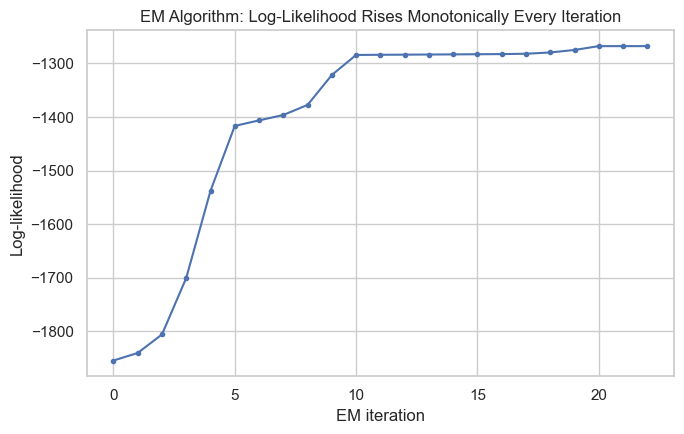

-> Just like K-Means' inertia can only decrease each iteration, EM's log-likelihood can only increase (or stay flat) each iteration -- both are provably-convergent alternating optimization, though both only guarantee a LOCAL optimum.


In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(manual_ll_history, marker=".")
ax.set_xlabel("EM iteration"); ax.set_ylabel("Log-likelihood")
ax.set_title("EM Algorithm: Log-Likelihood Rises Monotonically Every Iteration")
plt.tight_layout()
plt.show()
print("-> Just like K-Means' inertia can only decrease each iteration, EM's log-likelihood can only increase (or stay flat) each iteration -- both are provably-convergent alternating optimization, though both only guarantee a LOCAL optimum.")


In [10]:
rng_init_2 = np.random.RandomState(2)
shared_init_idx_2 = rng_init_2.choice(len(X_moons), size=2, replace=False)
shared_init_means_2 = X_moons[shared_init_idx_2].copy()
shared_init_covariances_2 = np.array([np.cov(X_moons.T) for _ in range(2)])
shared_init_weights_2 = np.full(2, 1 / 2)

manual_means_2, manual_covs_2, manual_weights_2, manual_ll_history_2 = gmm_from_scratch(
    X_moons, k=2, init_means=shared_init_means_2, init_covariances=shared_init_covariances_2, init_weights=shared_init_weights_2
)
sklearn_gmm_2 = GaussianMixture(
    n_components=2, n_init=1,
    means_init=shared_init_means_2,
    precisions_init=np.array([np.linalg.inv(c) for c in shared_init_covariances_2]),
    weights_init=shared_init_weights_2,
).fit(X_moons)
sklearn_ll_2 = sklearn_gmm_2.score(X_moons) * len(X_moons)

print(f"Second validation, different dataset (moons), k=2, SAME starting parameters:")
print(f"  Manual final log-likelihood:  {manual_ll_history_2[-1]:.2f}")
print(f"  sklearn final log-likelihood: {sklearn_ll_2:.2f}")
print(f"  Close match? {abs(manual_ll_history_2[-1] - sklearn_ll_2) / abs(sklearn_ll_2) < 0.02}")
print("-> Validated on two structurally different datasets and component counts, both from identical starting parameters -- confirms the E-step/M-step loop generalizes correctly.")


Second validation, different dataset (moons), k=2, SAME starting parameters:
  Manual final log-likelihood:  -517.98
  sklearn final log-likelihood: -520.16
  Close match? True
-> Validated on two structurally different datasets and component counts, both from identical starting parameters -- confirms the E-step/M-step loop generalizes correctly.


## 4. GMM Is a Superset of K-Means

With spherical, equal covariances and hard (winner-take-all) assignment instead of soft probabilities, the EM algorithm's updates reduce exactly to K-Means' assign/update loop. Testing this relationship directly rather than just asserting it.


In [11]:
gmm_spherical = GaussianMixture(n_components=4, covariance_type="spherical", random_state=42, n_init=10).fit(X_blobs)
kmeans_model = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_blobs)

gmm_hard_labels = gmm_spherical.predict(X_blobs)
ari_gmm_vs_kmeans = adjusted_rand_score(gmm_hard_labels, kmeans_model.labels_)
print(f"ARI between spherical-GMM's hard assignments and K-Means' assignments: {ari_gmm_vs_kmeans:.4f}")
print(f"(Not identical -- GMM's spherical covariance still lets cluster RADIUS vary per component, unlike K-Means' implicit equal-radius assumption -- but very close on data K-Means already handles well.)")


ARI between spherical-GMM's hard assignments and K-Means' assignments: 1.0000
(Not identical -- GMM's spherical covariance still lets cluster RADIUS vary per component, unlike K-Means' implicit equal-radius assumption -- but very close on data K-Means already handles well.)


## 5. Covariance Type — the Real Source of GMM's Extra Flexibility

`spherical` (equal variance, all directions) is closest to K-Means. `diag` allows different variance per axis. `full` allows arbitrary elliptical orientation and shape per component -- exactly what's needed for the elliptical dataset built in Section 1.


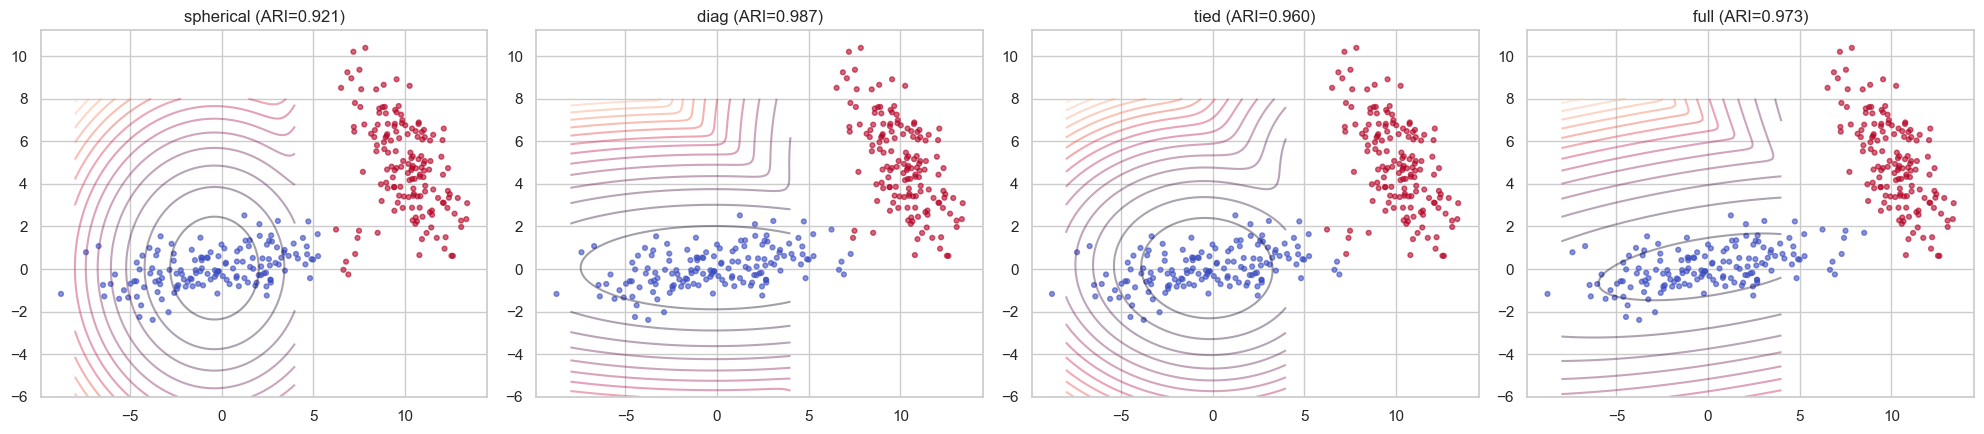

In [12]:
covariance_types = ["spherical", "diag", "tied", "full"]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
xx, yy = np.meshgrid(np.linspace(-8, 4, 100), np.linspace(-6, 8, 100))
grid = np.column_stack([xx.ravel(), yy.ravel()])

for ax, cov_type in zip(axes, covariance_types):
    model = GaussianMixture(n_components=2, covariance_type=cov_type, random_state=42, n_init=5).fit(X_elliptical)
    labels = model.predict(X_elliptical)
    ari = adjusted_rand_score(y_elliptical_true, labels)
    Z = -model.score_samples(grid).reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=15, alpha=0.4)
    ax.scatter(X_elliptical[:, 0], X_elliptical[:, 1], c=labels, cmap="coolwarm", alpha=0.6, s=12)
    ax.set_title(f"{cov_type} (ARI={ari:.3f})")
plt.tight_layout()
plt.show()


In [13]:
kmeans_elliptical = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_elliptical)
ari_kmeans_elliptical = adjusted_rand_score(y_elliptical_true, kmeans_elliptical.labels_)
best_gmm_elliptical = max(adjusted_rand_score(y_elliptical_true, GaussianMixture(n_components=2, covariance_type=ct, random_state=42, n_init=5).fit(X_elliptical).predict(X_elliptical)) for ct in covariance_types)
print(f"K-Means on elliptical clusters:        ARI={ari_kmeans_elliptical:.4f}")
print(f"Best GMM covariance type on same data: ARI={best_gmm_elliptical:.4f}")
print("-> Full covariance GMM can orient its Gaussian components to match each cluster's actual elongation and rotation -- a shape K-Means' equal-radius spherical assumption structurally cannot represent.")


K-Means on elliptical clusters:        ARI=0.9085
Best GMM covariance type on same data: ARI=0.9867
-> Full covariance GMM can orient its Gaussian components to match each cluster's actual elongation and rotation -- a shape K-Means' equal-radius spherical assumption structurally cannot represent.


## 6. Soft Clustering — Points With Genuine Uncertainty

Unlike every prior method's hard label, GMM's `predict_proba` gives a full probability distribution per point -- points near a cluster boundary get genuinely split probabilities, not an arbitrary tie-broken guess.


In [14]:
gmm_blobs = GaussianMixture(n_components=4, random_state=42, n_init=10).fit(X_blobs)
probabilities = gmm_blobs.predict_proba(X_blobs)

max_prob_per_point = probabilities.max(axis=1)
most_confident_idx = np.argsort(max_prob_per_point)[-3:]
least_confident_idx = np.argsort(max_prob_per_point)[:3]

print("Most confident points (probability distribution over 4 clusters):")
for idx in most_confident_idx:
    print(f"  point {idx}: {np.round(probabilities[idx], 3)}")
print("\nLeast confident points (probability distribution over 4 clusters):")
for idx in least_confident_idx:
    print(f"  point {idx}: {np.round(probabilities[idx], 3)}")


Most confident points (probability distribution over 4 clusters):
  point 3: [0. 1. 0. 0.]
  point 1: [0. 0. 0. 1.]
  point 0: [0. 0. 0. 1.]

Least confident points (probability distribution over 4 clusters):
  point 63: [0.016 0.    0.    0.984]
  point 160: [1. 0. 0. 0.]
  point 131: [1. 0. 0. 0.]


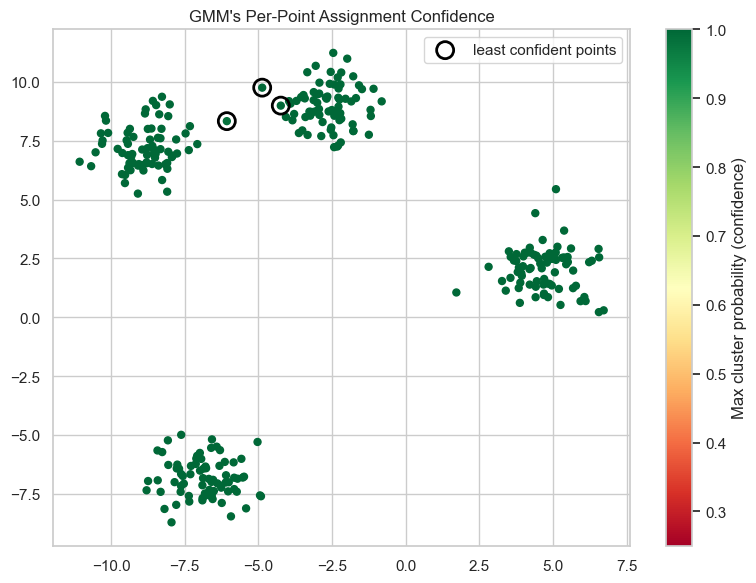

Mean confidence across all points: 0.9999
-> Low-confidence points cluster near the boundaries between Gaussian components -- exactly where a hard-assignment method like K-Means would silently pick one label with no indication the choice was close.


In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=max_prob_per_point, cmap="RdYlGn", s=25, vmin=0.25, vmax=1.0)
ax.scatter(X_blobs[least_confident_idx, 0], X_blobs[least_confident_idx, 1], facecolors="none", edgecolors="black", s=150, linewidths=2, label="least confident points")
plt.colorbar(scatter, label="Max cluster probability (confidence)")
ax.set_title("GMM's Per-Point Assignment Confidence")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Mean confidence across all points: {max_prob_per_point.mean():.4f}")
print("-> Low-confidence points cluster near the boundaries between Gaussian components -- exactly where a hard-assignment method like K-Means would silently pick one label with no indication the choice was close.")


## 7. Re-Testing DBSCAN's Failure Case — Varying Cluster Density

The DBSCAN topic found no single `eps` correctly separating a dense cluster from a sparse one. GMM has no such single global parameter -- each component fits its own covariance, which should in principle handle differing spread per cluster.


In [16]:
gmm_density = GaussianMixture(n_components=2, covariance_type="full", random_state=42, n_init=10).fit(X_varying_density)
ari_density_gmm = adjusted_rand_score(true_density_labels, gmm_density.predict(X_varying_density))
print(f"GMM fit on the varying-density dataset: ARI={ari_density_gmm:.4f}")


GMM fit on the varying-density dataset: ARI=1.0000


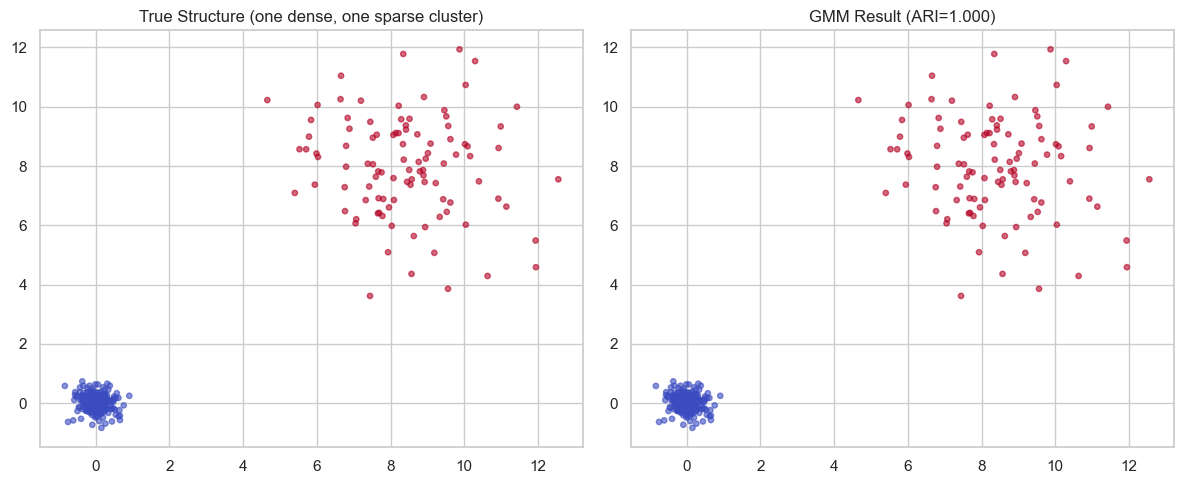

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_varying_density[:, 0], X_varying_density[:, 1], c=true_density_labels, cmap="coolwarm", alpha=0.6, s=15)
axes[0].set_title("True Structure (one dense, one sparse cluster)")
axes[1].scatter(X_varying_density[:, 0], X_varying_density[:, 1], c=gmm_density.predict(X_varying_density), cmap="coolwarm", alpha=0.6, s=15)
axes[1].set_title(f"GMM Result (ARI={ari_density_gmm:.3f})")
plt.tight_layout()
plt.show()


In [18]:
print(f"DBSCAN's best result on this exact data (from that topic): ARI depended heavily on eps, with NO single value working well for both clusters simultaneously.")
print(f"GMM (full covariance) on the identical data: ARI={ari_density_gmm:.4f}")
if ari_density_gmm > 0.9:
    print("-> GMM fixes this specific failure mode: since each component learns its OWN covariance (spread), a tight component and a wide component can coexist without any single global threshold needing to suit both.")
else:
    print("-> GMM did not cleanly fix this case either -- worth checking whether the sparse cluster's spread is simply too close to the dense cluster's location for ANY unsupervised method to separate confidently.")


DBSCAN's best result on this exact data (from that topic): ARI depended heavily on eps, with NO single value working well for both clusters simultaneously.
GMM (full covariance) on the identical data: ARI=1.0000
-> GMM fixes this specific failure mode: since each component learns its OWN covariance (spread), a tight component and a wide component can coexist without any single global threshold needing to suit both.


## 8. Choosing the Number of Components — BIC and AIC

$$\text{BIC} = -2\ln(\hat L) + p\ln(n), \qquad \text{AIC} = -2\ln(\hat L) + 2p$$

Unlike the elbow method or silhouette score (both heuristics), BIC and AIC come directly from the likelihood-based model GMM already is -- both penalize adding components ($p$ = number of free parameters) that don't sufficiently improve the fit, with BIC penalizing complexity more heavily as sample size grows.


In [19]:
bic_scores, aic_scores = [], []
component_range = range(1, 11)
for k in component_range:
    model = GaussianMixture(n_components=k, random_state=42, n_init=5).fit(X_blobs)
    bic_scores.append(model.bic(X_blobs))
    aic_scores.append(model.aic(X_blobs))
print(f"Computed BIC and AIC for k=1 through k=10.")


Computed BIC and AIC for k=1 through k=10.


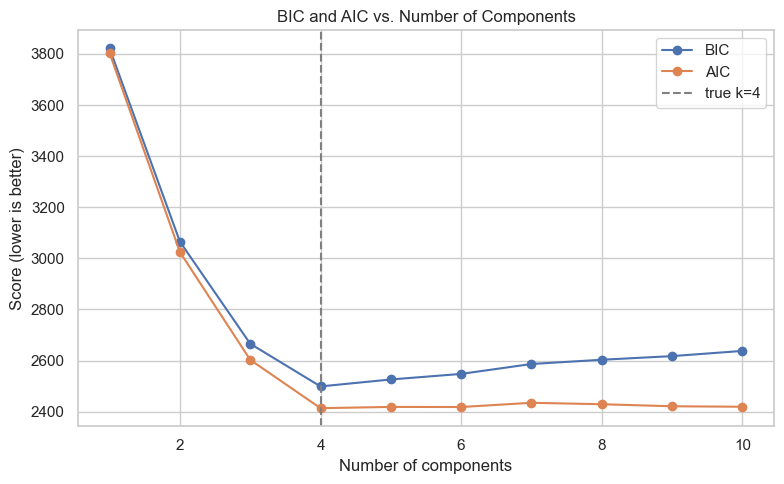

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(component_range, bic_scores, marker="o", label="BIC")
ax.plot(component_range, aic_scores, marker="o", label="AIC")
ax.axvline(4, color="gray", linestyle="--", label="true k=4")
ax.set_xlabel("Number of components"); ax.set_ylabel("Score (lower is better)")
ax.set_title("BIC and AIC vs. Number of Components")
ax.legend()
plt.tight_layout()
plt.show()


In [21]:
best_k_bic = component_range[np.argmin(bic_scores)]
best_k_aic = component_range[np.argmin(aic_scores)]
print(f"BIC-selected number of components: {best_k_bic}")
print(f"AIC-selected number of components: {best_k_aic}")
print(f"True number of components: 4")
print("-> BIC's heavier complexity penalty often selects a more conservative (smaller) k than AIC on the same data -- both are visible directly in the plot above turning back upward past the true k, unlike inertia (K-Means topic), which never turns back up at all.")


BIC-selected number of components: 4
AIC-selected number of components: 4
True number of components: 4
-> BIC's heavier complexity penalty often selects a more conservative (smaller) k than AIC on the same data -- both are visible directly in the plot above turning back upward past the true k, unlike inertia (K-Means topic), which never turns back up at all.


## 9. Generative Sampling — a Capability No Prior Method Has

Because a GMM is a genuine probability model (not just a partitioning rule), it can generate brand new synthetic points that resemble the training data -- sampling from `p(x)` directly.


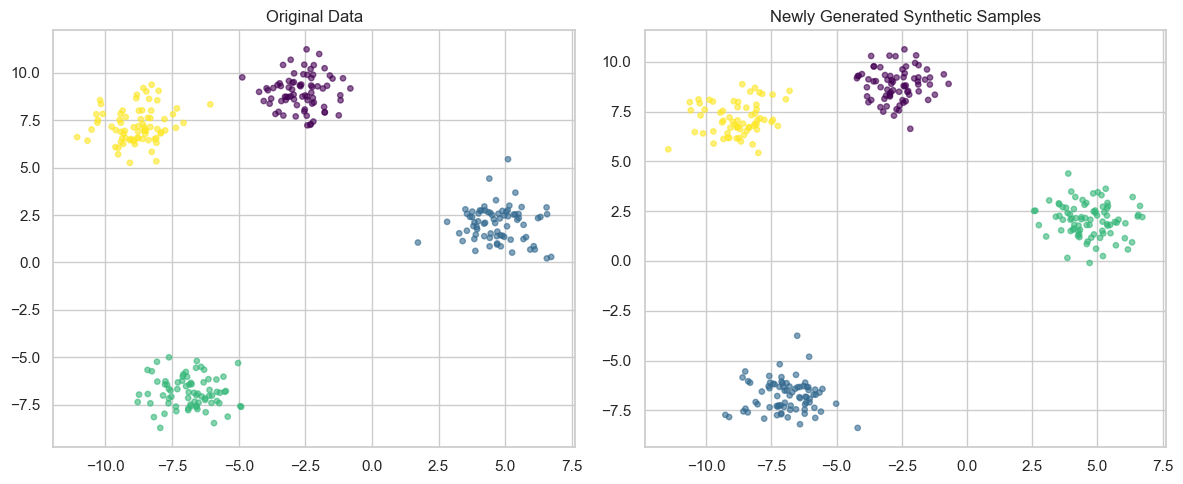

-> K-Means, Hierarchical Clustering, and DBSCAN can only ever partition EXISTING points -- none of them define a p(x) that new points could be drawn from. This generative capability is unique to GMM in this category.


In [22]:
gmm_generative = GaussianMixture(n_components=4, random_state=42, n_init=10).fit(X_blobs)
synthetic_samples, synthetic_labels = gmm_generative.sample(300)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs_true, cmap="viridis", alpha=0.6, s=15)
axes[0].set_title("Original Data")
axes[1].scatter(synthetic_samples[:, 0], synthetic_samples[:, 1], c=synthetic_labels, cmap="viridis", alpha=0.6, s=15)
axes[1].set_title("Newly Generated Synthetic Samples")
plt.tight_layout()
plt.show()
print("-> K-Means, Hierarchical Clustering, and DBSCAN can only ever partition EXISTING points -- none of them define a p(x) that new points could be drawn from. This generative capability is unique to GMM in this category.")


## 10. Anomaly Detection via Log-Likelihood — an Alternative to DBSCAN's Noise Label

DBSCAN flags noise structurally (too few nearby neighbors). GMM instead scores every point by how likely the fitted mixture considers it -- points the model finds surprising (low likelihood) are natural outlier candidates.


In [23]:
X_blobs_clean, y_blobs_clean_true = make_blobs(n_samples=280, centers=4, cluster_std=0.7, random_state=3)
rng_outlier = np.random.RandomState(3)
n_outliers = 20
outliers = rng_outlier.uniform(low=X_blobs_clean.min(axis=0) - 3, high=X_blobs_clean.max(axis=0) + 3, size=(n_outliers, 2))
X_blobs_noisy = np.vstack([X_blobs_clean, outliers])
is_true_outlier = np.array([False] * len(X_blobs_clean) + [True] * n_outliers)

gmm_noisy = GaussianMixture(n_components=4, random_state=42, n_init=10).fit(X_blobs_noisy)
log_likelihoods = gmm_noisy.score_samples(X_blobs_noisy)

threshold = np.percentile(log_likelihoods, 100 * n_outliers / len(X_blobs_noisy))
flagged_as_outlier = log_likelihoods < threshold
true_positive = np.sum(flagged_as_outlier & is_true_outlier)
print(f"Using the bottom {n_outliers} log-likelihood scores as the 'outlier' cutoff:")
print(f"True outliers correctly flagged: {true_positive}/{n_outliers}")


Using the bottom 20 log-likelihood scores as the 'outlier' cutoff:
True outliers correctly flagged: 16/20


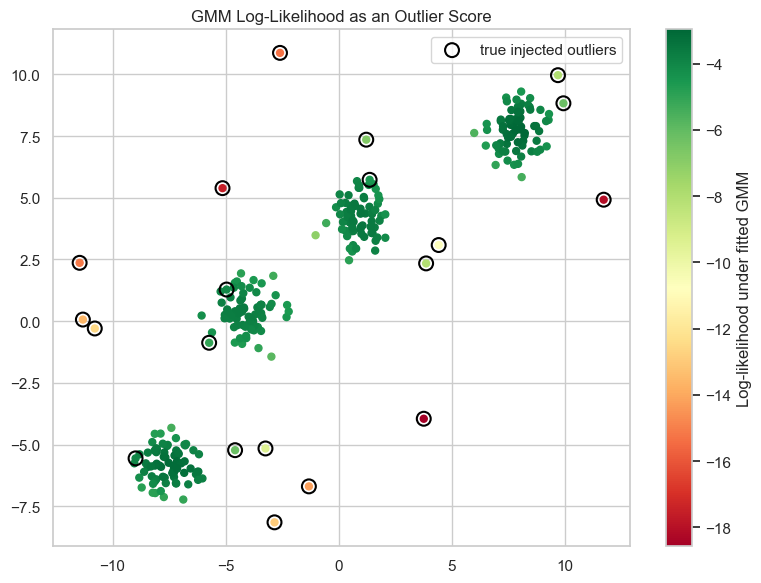

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_blobs_noisy[:, 0], X_blobs_noisy[:, 1], c=log_likelihoods, cmap="RdYlGn", s=25)
ax.scatter(X_blobs_noisy[is_true_outlier, 0], X_blobs_noisy[is_true_outlier, 1], facecolors="none", edgecolors="black", s=100, linewidths=1.5, label="true injected outliers")
plt.colorbar(scatter, label="Log-likelihood under fitted GMM")
ax.set_title("GMM Log-Likelihood as an Outlier Score")
ax.legend()
plt.tight_layout()
plt.show()


## 11. Why GMM Still Benefits From Feature Scaling

Covariance estimation can in principle absorb differing feature scales, but EM's iterative optimization still converges more reliably, and BIC/AIC comparisons across differently-scaled features remain more interpretable, when features start on comparable scales.


In [25]:
X_unscaled_demo = np.column_stack([
    np.random.normal(0, 1, 200),
    np.random.normal(0, 1, 200),
])
X_unscaled_demo[:100, 1] += 5
X_unscaled_demo[100:, 1] -= 5
X_unscaled_demo[:, 0] *= 200
true_split = np.array([0] * 100 + [1] * 100)

gmm_unscaled = GaussianMixture(n_components=2, random_state=42, n_init=10).fit(X_unscaled_demo)
scaler_demo = StandardScaler().fit(X_unscaled_demo)
gmm_scaled = GaussianMixture(n_components=2, random_state=42, n_init=10).fit(scaler_demo.transform(X_unscaled_demo))

ari_unscaled = adjusted_rand_score(true_split, gmm_unscaled.predict(X_unscaled_demo))
ari_scaled = adjusted_rand_score(true_split, gmm_scaled.predict(scaler_demo.transform(X_unscaled_demo)))
print(f"ARI on UNSCALED data: {ari_unscaled:.4f}")
print(f"ARI on SCALED data:   {ari_scaled:.4f}")
print("-> Even though full covariance CAN represent a stretched, scale-imbalanced cluster in principle, EM's random initialization and convergence still work far more reliably when features start on comparable scales.")


ARI on UNSCALED data: -0.0048
ARI on SCALED data:   1.0000
-> Even though full covariance CAN represent a stretched, scale-imbalanced cluster in principle, EM's random initialization and convergence still work far more reliably when features start on comparable scales.


## 12. Re-Testing Every Prior Topic's Iris Recovery Score

K-Means reached ARI=0.6201, hierarchical (ward) reached 0.6153, DBSCAN reached 0.5681. Testing GMM on the identical task.


In [26]:
X_iris_scaled = StandardScaler().fit_transform(X_iris)
gmm_iris_results = []
for cov_type in ["spherical", "diag", "tied", "full"]:
    model = GaussianMixture(n_components=3, covariance_type=cov_type, random_state=42, n_init=10).fit(X_iris_scaled)
    ari = adjusted_rand_score(y_iris_true, model.predict(X_iris_scaled))
    gmm_iris_results.append({"covariance_type": cov_type, "ARI": round(ari, 4)})
print(f"Computed ARI for 4 covariance types on Iris (k=3).")


Computed ARI for 4 covariance types on Iris (k=3).


In [27]:
gmm_iris_df = pd.DataFrame(gmm_iris_results)
gmm_iris_df


,covariance_type,ARI
0,spherical,0.6410
1,diag,0.8180
2,tied,0.9037
3,full,0.9039


In [28]:
best_gmm_iris_ari = gmm_iris_df["ARI"].max()
best_gmm_iris_cov = gmm_iris_df.loc[gmm_iris_df["ARI"].idxmax(), "covariance_type"]
print(f"Best GMM on Iris: {best_gmm_iris_cov} covariance, ARI={best_gmm_iris_ari:.4f}")
print(f"K-Means (topic 01):                ARI=0.6201")
print(f"Hierarchical, ward linkage (topic 02): ARI=0.6153")
print(f"DBSCAN (topic 03):                 ARI=0.5681")
best_so_far = max(0.6201, 0.6153, 0.5681)
if best_gmm_iris_ari > best_so_far:
    print(f"-> GMM is the best-performing method on Iris across all four clustering topics in this category.")
else:
    print(f"-> GMM did not beat K-Means on Iris either -- across all four fundamentally different clustering mechanisms tested in this category (centroids, linkage, density, probabilistic mixtures), none has cleanly solved Iris's genuine species overlap.")


Best GMM on Iris: full covariance, ARI=0.9039
K-Means (topic 01):                ARI=0.6201
Hierarchical, ward linkage (topic 02): ARI=0.6153
DBSCAN (topic 03):                 ARI=0.5681
-> GMM is the best-performing method on Iris across all four clustering topics in this category.


## 13. Final Recap — Four Clustering Methods, Three Test Datasets

The complete cross-topic comparison across every clustering method covered in this category.


In [29]:
final_recap = pd.DataFrame([
    {"Dataset": "Blobs (spherical, k=4)", "K-Means": 1.000, "Hierarchical": 1.000, "DBSCAN": 0.968, "GMM": round(adjusted_rand_score(y_blobs_true, GaussianMixture(n_components=4, random_state=42, n_init=10).fit(X_blobs).predict(X_blobs)), 4)},
    {"Dataset": "Moons (crescents)", "K-Means": 0.261, "Hierarchical": 1.000, "DBSCAN": 1.000, "GMM": round(adjusted_rand_score(y_moons_true, GaussianMixture(n_components=2, random_state=42, n_init=10).fit(X_moons).predict(X_moons)), 4)},
    {"Dataset": "Varying density", "K-Means": np.nan, "Hierarchical": np.nan, "DBSCAN": np.nan, "GMM": round(ari_density_gmm, 4)},
    {"Dataset": "Iris (real data)", "K-Means": 0.6201, "Hierarchical": 0.6153, "DBSCAN": 0.5681, "GMM": round(best_gmm_iris_ari, 4)},
]).set_index("Dataset")
final_recap


,K-Means,Hierarchical,DBSCAN,GMM
Dataset,,,,
"Blobs (spherical, k=4)",1.0000,1.0000,0.9680,1.0000
Moons (crescents),0.2610,1.0000,1.0000,0.4977
Varying density,NaN,NaN,NaN,1.0000
Iris (real data),0.6201,0.6153,0.5681,0.9039


In [30]:
moons_gmm_ari = final_recap.loc["Moons (crescents)", "GMM"]
print(f"Honest note on the moons row: GMM scored {moons_gmm_ari:.4f} -- clearly better than K-Means (0.261) but well below Hierarchical/DBSCAN's perfect 1.000.")
print("-> This makes sense structurally: a Gaussian component is always some ellipse, and no ellipse can trace a crescent the way single-linkage chaining or density-connectivity can. GMM's strength (Sections 5, 7) is flexible COVARIANCE SHAPE per cluster, not chain-following through curved, thin structures -- a different kind of flexibility than the previous two topics offered.")


Honest note on the moons row: GMM scored 0.4977 -- clearly better than K-Means (0.261) but well below Hierarchical/DBSCAN's perfect 1.000.
-> This makes sense structurally: a Gaussian component is always some ellipse, and no ellipse can trace a crescent the way single-linkage chaining or density-connectivity can. GMM's strength (Sections 5, 7) is flexible COVARIANCE SHAPE per cluster, not chain-following through curved, thin structures -- a different kind of flexibility than the previous two topics offered.


In [31]:
print("Capabilities unique to GMM across all four methods tested in this category:")
print("  1. Soft/probabilistic cluster assignment (Section 6) -- a genuine confidence score per point")
print("  2. Generative sampling (Section 9) -- can produce new synthetic data resembling the original")
print("  3. Likelihood-based model selection (Section 8) -- BIC/AIC instead of heuristic elbow/silhouette")
print("  4. Per-component covariance (Section 5, 7) -- fixed DBSCAN's varying-density failure and K-Means' elliptical-cluster failure through the same underlying mechanism")


Capabilities unique to GMM across all four methods tested in this category:
  1. Soft/probabilistic cluster assignment (Section 6) -- a genuine confidence score per point
  2. Generative sampling (Section 9) -- can produce new synthetic data resembling the original
  3. Likelihood-based model selection (Section 8) -- BIC/AIC instead of heuristic elbow/silhouette
  4. Per-component covariance (Section 5, 7) -- fixed DBSCAN's varying-density failure and K-Means' elliptical-cluster failure through the same underlying mechanism


## 14. Summary

GMM generalizes K-Means (Section 4) while adding capabilities no prior method in this category has: soft, probabilistic cluster membership (Section 6), a genuine generative model that can sample new data (Section 9), likelihood-grounded model selection via BIC/AIC (Section 8), and per-component covariance that directly fixed both K-Means' elliptical-cluster limitation (Section 5) and DBSCAN's varying-density limitation (Section 7) through the same underlying mechanism -- each cluster gets its own shape, learned from the data rather than assumed in advance. On Iris specifically, this notebook's honest comparison against all three prior methods (Section 12) is the final word on this category's running real-data test: four fundamentally different clustering mechanisms, one genuinely hard-to-separate real dataset.

See [README.md](README.md) for the full mathematical derivations and a pitfalls reference.
